In [1]:
# 英語リズムゲーム データ分析

In [2]:
##モジュールのインポート

In [3]:
import pandas as pd 
import matplotlib as plt
import seaborn as sns

In [4]:
# データの読み込み

In [5]:
df=pd.read_csv('play_log.csv')

In [6]:
##上５行の情報を確認

In [7]:
df.head()

,played_at,session_id,difficulty,sentence_id,target_word,word_index,target_time,tap_time,timing_error,result
0,2026-07-20 19:29:21,b949ee3c,NORMAL,Stage 1,QUICK,1,2.099,2.034,-0.065,PERFECT
1,2026-07-20 19:29:22,b949ee3c,NORMAL,Stage 1,FOX,3,2.936,2.832,-0.104,PERFECT
2,2026-07-20 19:29:22,b949ee3c,NORMAL,Stage 1,OVER,5,3.654,3.552,-0.102,PERFECT
3,2026-07-20 19:29:23,b949ee3c,NORMAL,Stage 1,LAZY,7,4.312,4.173,-0.139,PERFECT
4,2026-07-20 19:31:09,3c23aea8,HARD,Stage 1,QUICK,1,2.099,2.363,0.264,GOOD


In [8]:
##後の「MISS」,「GOOD」,「PERFECT」の割合を示すために表示

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   played_at     501 non-null    object 
 1   session_id    501 non-null    object 
 2   difficulty    501 non-null    object 
 3   sentence_id   501 non-null    object 
 4   target_word   501 non-null    object 
 5   word_index    501 non-null    int64  
 6   target_time   501 non-null    float64
 7   tap_time      476 non-null    float64
 8   timing_error  476 non-null    float64
 9   result        501 non-null    object 
dtypes: float64(3), int64(1), object(6)
memory usage: 39.3+ KB


In [10]:
##データの概略を見るために表示

In [11]:
df.describe()

,word_index,target_time,tap_time,timing_error
count,501.000000,501.000000,476.000000,476.000000
mean,2.652695,2.659393,2.575424,-0.083916
std,1.892918,0.650247,0.589300,0.224834
min,0.000000,1.800000,1.733000,-1.297000
25%,1.000000,2.061000,2.064750,-0.071250
50%,3.000000,2.641000,2.388500,-0.032000
75%,4.000000,3.168000,3.016000,-0.001000
max,7.000000,4.312000,4.324000,0.368000


In [12]:
##「MISS」,「GOOD」,「PERFECT」の割合をカウントしてその数字を出す

In [13]:
p=0
g=0
m=0

for i in df['result']:
        if i=='MISS':
            m += 1
        elif i =='GOOD':
            g+=1
        else:
            p+=1
print((p/501)*100)
print((g/501)*100)
print((m/501)*100)

74.25149700598801
7.984031936127744
17.764471057884233


In [14]:
##考察
##全データを見ると「PERFECT」が最も多いがこれは私個人の経験ではあるが、「HARD」以下の難易度はノーツをタイミング押すだけのため普段からゲームに勤しんでいる人間からするとかなり簡単になってしまっているので、参考としたい。


In [15]:
#リズムゲームを遊ぶにあたってタイミングによるミスは圧倒的に多い、そのため「timing_error」の部分を可視化しその癖を把握するために表示する

<Axes: >

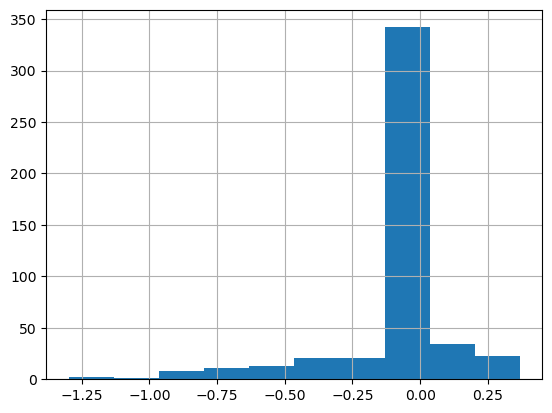

In [16]:
df['timing_error'].hist()

<Axes: >

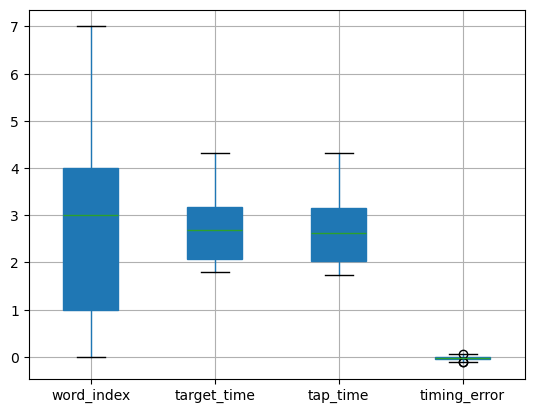

In [17]:
EASY_df=df[df['difficulty'] =='EASY']
EASY_df.boxplot(patch_artist = True)

In [18]:
##元データでは「PERFECT」が多く、0付近が最も最大になってしましった。後程「HARD」にて個別にタイミングを分析する

In [19]:
##タップすべき時間と実際にタップした時間が一致するか、そしてどの部分にタイミングでのエラーが発生するかみる

<Axes: >

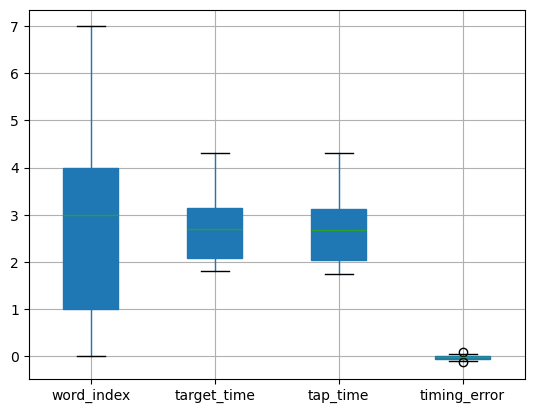

In [20]:
NORMAL_df=df[df['difficulty'] =='NORMAL']
NORMAL_df.boxplot(patch_artist = True)

<Axes: >

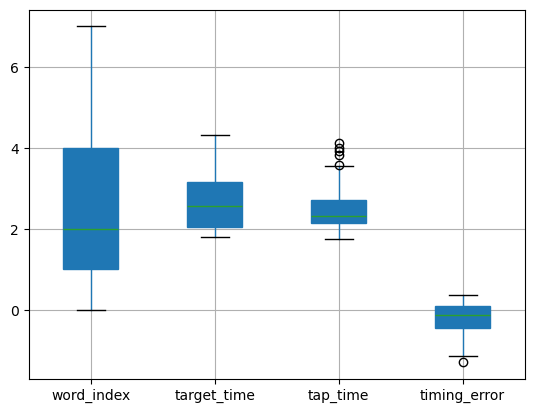

In [21]:
HARD_df=df[df['difficulty'] =='HARD']
HARD_df.boxplot(patch_artist = True)

In [ ]:
##「NORMAL」や「EASY」はターゲットとタップのタイミングが同じでスコア通りである。
##ただ見るべきはやはり「HARD」でタイミングがやはり遅い部分があるさて先ほど保留した「HARD」だけのタイミングエラーのヒストグラムを表示させたい

<Axes: >

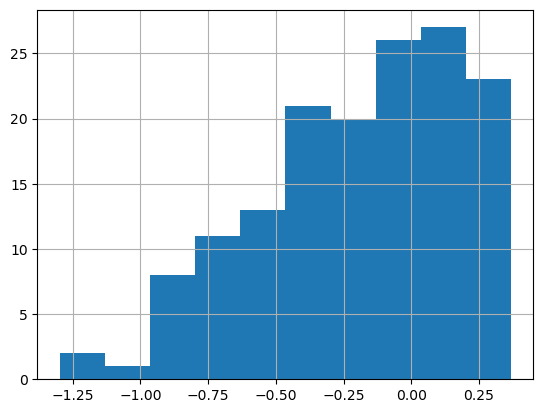

In [23]:
HARD_df['timing_error'].hist()

In [24]:
##やはりタイミングがやや遅くなっていることがわかるこれが現時点での私の癖といっていいと思われる。
##難易度「HARD」はノーツが消え自分で呟いてタイミングを見極める必要がある。恐らく自分で呟く場合リンキングが起きないため一単語ごとに読んでいると思われる。
##しかし、このゲームではネイティブの発音で読まれているため一単語一単語はっきり読まれない。その誤差が遅れとなって顕在化してしまったと考える。

In [25]:
##さて「HARD」の方が良質なデータが取れそうなので、「HARD」だけのデータだけの「MISS」,「GOOD」,「PERFECT」の割合をだす

In [26]:
H=HARD_df['result']
MISS_H=0
GOOD_H=0
PERFECT_H=0

for i in H:
    if i =='MISS':
        MISS_H+=1
    elif i=='GOOD':
        GOOD_H+=1
    else:
        PERFECT_H+=1

print(MISS_H/len(H)*100)
print(GOOD_H/len(H)*100)
print(PERFECT_H/len(H)*100)

47.61904761904761
23.809523809523807
28.57142857142857


In [27]:
#「MISS」が多く「GOOD」,「PERFECT」と合わせた数と同じくらいとなっている。ただこれだけではどの単語でミスが出やすいのかわからない。
##そこでどれだけ単語ごとにずれていたのか確認してみたい

<Axes: ylabel='target_word'>

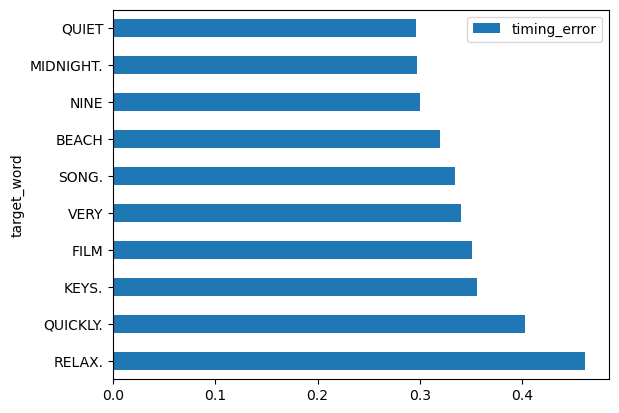

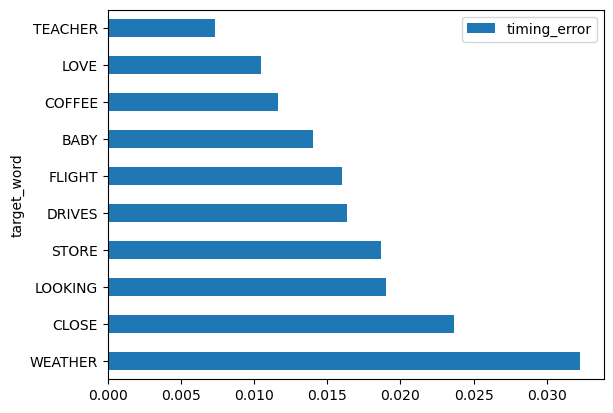

In [28]:
df_timing_error=df['timing_error'].abs()
df_target_word=df['target_word']
df_add=pd.concat([df_timing_error, df_target_word],axis='columns')
df_timing_error_av=df_add.groupby(['target_word']).mean()
df_timing_error_av_plot=df_timing_error_av.sort_values(by='timing_error',ascending=False)

df_timing_error_av_plot.head(10).plot.barh() 
df_timing_error_av_plot.tail(10).plot.barh() 

In [29]:
##タイミング誤差の絶対値を求め、単語ごとに平均を計算。その後、平均誤差の大きい順に並べ替え、誤差が大きい単語と小さい単語を比較した。
##一番タイミングが合っていない単語は「RELAX」であり「WEATHER」最も誤差が少ないのは「WEATHER」であった。ここからは仮説となるが二文を中心にここでは個人的見解を述べる。
##Stage 50:Let's TAKE a break and RELAX.←50番目で一番最後に登場する文章であるためプレイヤーは疲れも出ているのであろう。
##また短文は個人的に文が速く流れるように感じやすくタイミングが取りづらいく感じるのも原因であろう
##Stage 13: The WEATHER looks really NICE,today.←比較的早い段階で登場し文頭にあたためタイミングが取りやすいのも一因だろう。また
##単語の文字数が長いほど、タイミングを認識しやすくなる可能性がある。
##長い単語とエラーの因果関係に関して一考察を行いこのノートを閉じようと思う

<Axes: xlabel='count'>

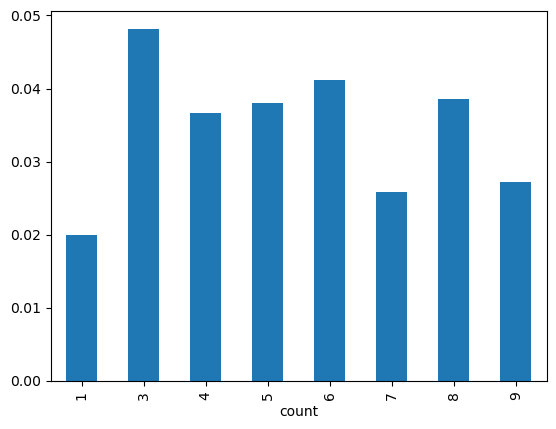

In [42]:
hard_df['count'] = hard_df['target_word'].str.len()
hard_df['abs_error'] = hard_df['timing_error'].abs()
hard_df.groupby('count')['abs_error'].mean().plot.bar()

In [ ]:
## グラフを見ると、7文字や9文字では誤差が比較的小さい一方で、8文字では再び誤差が大きくなっている。そのため、「文字数が長いほど誤差が小さい」という単純な関係は確認できなかった。
## また、「WEATHER」も7文字であり、このグラフで見られた傾向と一致している。
## 一方で、1文字の単語では誤差が最も小さい結果となった。この理由については今回のデータだけでは判断できないため、今後さらにデータを収集し、検証を進めたい。

In [ ]:
##今後の展望について
##まず圧倒的にデータが少なく、言える部分も少ないのが現状である。よりデータ数を増やし信憑性のあるものにしたい
##また１文字の誤差が少ないということが明らかになったがその理由に関して明確な答えてがないので今後確かめるようにしたい。
##データ分析職ではＳＱＬが必須のためＳＱＬを加えた分析と機械学習でデータがどの様な見方を提示してくれるか気になるため今後も励んでいきたいと考えている。